In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
path = r"C:/Users/ASUS/Downloads/archive/job_applicants_raw.csv"
df = pd.read_csv(path)
df

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552,C++;Python;Git;PostgreSQL,4,0
1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932,C++;Python,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73457,<35,No,Undergraduate,1,Man,No,Dev,7,2,Germany,41058,C#;HTML/CSS;JavaScript;TypeScript;Docker;Kuber...,13,1
73458,>35,No,Undergraduate,1,Man,No,Dev,21,16,United States of America,115000,C#;HTML/CSS;Java;JavaScript;npm;ASP.NET Core ;...,11,1
73459,<35,No,Undergraduate,1,Man,No,Dev,4,3,Nigeria,57720,HTML/CSS;JavaScript;TypeScript;Docker;Express;...,12,1
73460,<35,Yes,Undergraduate,1,Man,Yes,Dev,5,1,United States of America,70000,C#;HTML/CSS;JavaScript;SQL;TypeScript;npm;Yarn...,15,1


In [52]:
df.columns

Index(['Age', 'Accessibility', 'EdLevel', 'Employment', 'Gender',
       'MentalHealth', 'MainBranch', 'YearsCode', 'YearsCodePro', 'Country',
       'PreviousSalary', 'HaveWorkedWith', 'ComputerSkills', 'Employed'],
      dtype='object')

In [53]:
df.shape

(73462, 14)

In [54]:
df.dtypes

Age               object
Accessibility     object
EdLevel           object
Employment         int64
Gender            object
MentalHealth      object
MainBranch        object
YearsCode          int64
YearsCodePro       int64
Country           object
PreviousSalary     int64
HaveWorkedWith    object
ComputerSkills     int64
Employed           int64
dtype: object

In [55]:
df.isnull().sum()

Age                0
Accessibility      0
EdLevel            0
Employment         0
Gender             0
MentalHealth       0
MainBranch         0
YearsCode          0
YearsCodePro       0
Country            0
PreviousSalary     0
HaveWorkedWith    63
ComputerSkills     0
Employed           0
dtype: int64

Checking and understanding the target variable from the dataset

In [56]:
df['Employed'].value_counts()

Employed
1    39392
0    34070
Name: count, dtype: int64

In [57]:
df['Employed'].value_counts(normalize = True)*100

Employed
1    53.622281
0    46.377719
Name: proportion, dtype: float64

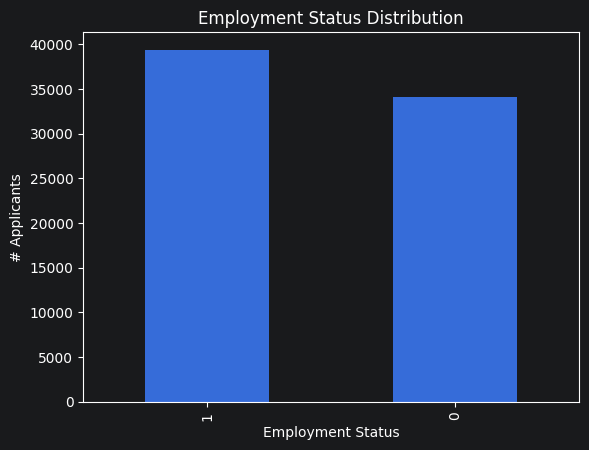

In [58]:
#Bar chat
df["Employed"].value_counts().plot(kind = "bar")

plt.title("Employment Status Distribution")
plt.xlabel("Employment Status")
plt.ylabel("# Applicants")
plt.show()

In [59]:
#Employment rate
employment_rate = df['Employed'].mean()*100
print(f'Employment Rate: {employment_rate: .2f}%')

Employment Rate:  53.62%


Data Cleaning

In [60]:
df[df.duplicated()]

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
6664,>35,No,Master,0,Man,No,Dev,25,15,Italy,129718,Go;Java;JavaScript;Kotlin;Node.js;Rust;TypeScr...,16,1
7329,<35,No,Undergraduate,1,Man,No,Dev,4,0,India,2653,Java;Python;Docker;Git;Kubernetes;Flask;Spring...,10,0
7783,>35,No,Undergraduate,1,Man,No,Dev,39,27,Croatia,26124,SQL;Oracle,2,0
46025,<35,No,Undergraduate,1,Man,No,Dev,17,10,Finland,44796,C#;Java;Python;Ansible;Docker;Unity 3D;Microso...,10,1


In [61]:
df.duplicated().sum()

np.int64(4)

In [62]:
df[df['HaveWorkedWith'].isnull()]

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
1161,>35,No,Undergraduate,1,Man,Yes,Dev,36,32,Switzerland,96566,NaN,0,0
2443,>35,No,Other,1,Man,No,Dev,7,6,United States of America,85000,NaN,0,0
2533,>35,No,PhD,1,Man,No,NotDev,37,0,Germany,76020,NaN,0,0
2657,<35,No,Master,0,Woman,No,Dev,11,5,Portugal,31428,NaN,0,0
5797,<35,No,Undergraduate,1,Man,No,Dev,8,4,India,70368,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69865,<35,No,Other,1,Man,No,Dev,0,0,Colombia,6036,NaN,0,0
71795,<35,No,Undergraduate,1,Man,No,Dev,7,3,Bangladesh,5460,NaN,0,0
72153,>35,Yes,Other,1,Man,No,NotDev,12,2,Germany,106644,NaN,0,0
72588,<35,No,Other,1,Man,Yes,Dev,10,6,Spain,41058,NaN,0,0


In [63]:
#Since only 63 rows are missing out of 73K+, we can safely label them:
df["HaveWorkedWith"] = df["HaveWorkedWith"].fillna("NotSpecified")

In [64]:
df

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552,C++;Python;Git;PostgreSQL,4,0
1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932,C++;Python,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73457,<35,No,Undergraduate,1,Man,No,Dev,7,2,Germany,41058,C#;HTML/CSS;JavaScript;TypeScript;Docker;Kuber...,13,1
73458,>35,No,Undergraduate,1,Man,No,Dev,21,16,United States of America,115000,C#;HTML/CSS;Java;JavaScript;npm;ASP.NET Core ;...,11,1
73459,<35,No,Undergraduate,1,Man,No,Dev,4,3,Nigeria,57720,HTML/CSS;JavaScript;TypeScript;Docker;Express;...,12,1
73460,<35,Yes,Undergraduate,1,Man,Yes,Dev,5,1,United States of America,70000,C#;HTML/CSS;JavaScript;SQL;TypeScript;npm;Yarn...,15,1


In [65]:
#creating a derived column
#1 Experience category
def experience_category(years):
  if years == 0:
    return "No professional experience"
  elif years <= 2:
    return "Junior"
  elif years <= 5:
    return "Intermediate"
  elif years <= 10:
    return "Senior"
  else:
    return "Highly Experienced"

df["ExperienceCategory"] = df["YearsCodePro"].apply(experience_category)


#2 Skill category
def skill_category(skills):
  if skills < 5:
    return "Low Skills"
  elif skills < 10:
    return "Moderate Skills"
  elif skills <= 20:
    return "High Skills"
  else:
    return "Very High Skills"

df["SkillCategory"] = df["ComputerSkills"].apply(skill_category)

Core Analysis Questions

In [66]:
#1 How does professional experience relate to employment?
df.groupby("ExperienceCategory")["Employed"].mean()*100

ExperienceCategory
Highly Experienced            54.768587
Intermediate                  53.207647
Junior                        51.487485
No professional experience    47.570506
Senior                        54.683973
Name: Employed, dtype: float64

In [67]:
#2 Do candidates with more computer skills have better employment outcomes?
df.groupby("SkillCategory")["Employed"].mean()*100

SkillCategory
High Skills         65.406281
Low Skills           0.756694
Moderate Skills     16.904668
Very High Skills    96.619234
Name: Employed, dtype: float64

In [68]:
#3 Which education levels have the highest employment rates?
df.groupby("EdLevel")["Employed"].agg(["count","mean"]).sort_values("mean",ascending = False)

,count,mean
EdLevel,,
NoHigherEd,3706,0.588505
Other,10843,0.584432
Undergraduate,37402,0.559917
Master,18903,0.485902
PhD,2608,0.286426


In [69]:
#4 which countries have the highest employment rates?
country_analysis = df.groupby("Country").agg(Applicants=("Employed","count"),EmploymentRate=("Employed","mean"))
country_analysis["EmploymentRate"]*=100

country_analysis.sort_values("Applicants",ascending = False).head(10)

,Applicants,EmploymentRate
Country,,
United States of America,14696,55.089820
Germany,5395,52.215014
India,5360,50.652985
United Kingdom of Great Britain and Northern Ireland,4688,52.346416
Canada,2779,53.004678
France,2650,51.471698
Brazil,2624,54.839939
Poland,1922,49.063476
Netherlands,1761,53.662692


In [70]:
#5 Which technologies are most common among employed candidates?
df["HaveWorkedWith"].head(10)

0                            C++;Python;Git;PostgreSQL
1    Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...
2               C;C++;Java;Perl;Ruby;Git;Ruby on Rails
3    Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...
4                                           C++;Python
5                   JavaScript;Python;Docker;Git;MySQL
6    C++;HTML/CSS;Java;JavaScript;Kotlin;Node.js;Ty...
7                                C++;Python;Docker;Git
8                                Python;Git;PostgreSQL
9                Delphi;Java;SQL;Docker;Git;PostgreSQL
Name: HaveWorkedWith, dtype: object

In [71]:
technologies = (df.assign(Technology = df["HaveWorkedWith"].str.split(";")).explode("Technology"))

In [72]:
employed_technologies = technologies[technologies["Employed"] == 1]

employed_technologies["Technology"].value_counts().head(20)

Technology
JavaScript              33720
HTML/CSS                27931
SQL                     25467
Docker                  24453
TypeScript              23080
Node.js                 22606
MySQL                   19032
AWS                     18843
Git                     18496
PostgreSQL              18142
React.js                17783
C#                      17267
Python                  16708
Microsoft SQL Server    16331
Java                    16020
jQuery                  15328
Bash/Shell              15201
MongoDB                 14756
SQLite                  14644
npm                     14568
Name: count, dtype: int64

In [73]:
import mysql.connector

In [74]:
connection = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Girish@8172",
    database="recruitment_analytics"
)

cursor = connection.cursor()

print("Connected successfully")

Connected successfully


In [75]:
df.info

<bound method DataFrame.info of        Age Accessibility        EdLevel  Employment     Gender MentalHealth  \
0      <35            No         Master           1        Man           No   
1      <35            No  Undergraduate           1        Man           No   
2      <35            No         Master           1        Man           No   
3      <35            No  Undergraduate           1        Man           No   
4      >35            No            PhD           0        Man           No   
...    ...           ...            ...         ...        ...          ...   
73457  <35            No  Undergraduate           1        Man           No   
73458  >35            No  Undergraduate           1        Man           No   
73459  <35            No  Undergraduate           1        Man           No   
73460  <35           Yes  Undergraduate           1        Man          Yes   
73461  <35            No         Master           1  NonBinary           No   

      MainBranch  Y

In [76]:
df.columns

Index(['Age', 'Accessibility', 'EdLevel', 'Employment', 'Gender',
       'MentalHealth', 'MainBranch', 'YearsCode', 'YearsCodePro', 'Country',
       'PreviousSalary', 'HaveWorkedWith', 'ComputerSkills', 'Employed',
       'ExperienceCategory', 'SkillCategory'],
      dtype='object')

In [77]:
df = df.rename(columns={
    "Age": "age",
    "Accessibility": "accessibility",
    "EdLevel": "ed_level",
    "Employment": "employment",
    "Gender": "gender",
    "MentalHealth": "mental_health",
    "MainBranch": "main_branch",
    "YearsCode": "years_code",
    "YearsCodePro": "years_code_pro",
    "Country": "country",
    "PreviousSalary": "previous_salary",
    "HaveWorkedWith": "have_worked_with",
    "ComputerSkills": "computer_skills",
    "Employed": "employed",
    "ExperienceCategory": "experience_category",
    "SkillCategory": "skill_category"
})

In [78]:
columns = [
    "age",
    "accessibility",
    "ed_level",
    "employment",
    "gender",
    "mental_health",
    "main_branch",
    "years_code",
    "years_code_pro",
    "country",
    "previous_salary",
    "have_worked_with",
    "computer_skills",
    "employed",
    "experience_category",
    "skill_category"
]

In [79]:
insert_query = """
INSERT INTO job_applicants (
    age,
    accessibility,
    ed_level,
    employment,
    gender,
    mental_health,
    main_branch,
    years_code,
    years_code_pro,
    country,
    previous_salary,
    have_worked_with,
    computer_skills,
    employed,
    experience_category,
    skill_category
)
VALUES (
    %s, %s, %s, %s,
    %s, %s, %s, %s,
    %s, %s, %s, %s,
    %s, %s, %s, %s
)
"""

In [80]:
data = [
    tuple(row)
    for row in df[columns].itertuples(
        index=False,
        name=None
    )
]

In [81]:
cursor.executemany(
    insert_query,
    data
)

connection.commit()

print(
    cursor.rowcount,
    "records inserted successfully"
)

73462 records inserted successfully


In [87]:
cursor.close()
connection.close()

In [86]:
cleaned_path = r"C:/Users/ASUS/Downloads/archive/job_applicants_cleaned.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
